# Used Car Listings — SQL Analysis (Phase 2)

Phase 1 answered these questions with pandas on a CSV. This phase rebuilds them as SQL against a real database, and asks a couple of questions pandas alone made awkward: JOINs across tables and ranking within groups.

**Setup:** the phase 1 cleaned data now lives in `data/processed/used_cars.db`, a SQLite database with two tables — `listings` (the cleaned car data) and `regions` (a lookup mapping each state to a US Census region, built so region-level questions can be a real JOIN instead of a manual dictionary). Schema in `sql/schema.sql`, every query below also lives standalone in `sql/queries.sql`.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100

conn = sqlite3.connect('../data/processed/used_cars.db')

## 1. Why a database instead of just the CSV?

A single flat file can't represent "each state belongs to one region" without repeating the region name on every row. Splitting that into its own `regions` table — one row per state — means the mapping is stored once, and any query that needs it just joins to get it. That's the core idea behind normalizing a schema instead of keeping everything in one wide table.

In [2]:
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

for t in tables['name']:
    n = pd.read_sql_query(f"SELECT COUNT(*) AS n FROM {t}", conn)['n'][0]
    print(f"{t}: {n} rows")

       name
0  listings
1   regions
listings: 2448 rows
regions: 52 rows


## 2. The basics

In [3]:
query = '''
SELECT COUNT(*) AS total_listings,
       MIN(price) AS min_price,
       MAX(price) AS max_price,
       ROUND(AVG(price), 0) AS avg_price
FROM listings;
'''
pd.read_sql_query(query, conn)

,total_listings,min_price,max_price,avg_price
0,2448,25,84900,19123.0


## 3. Which brands show up most, and what do they go for?

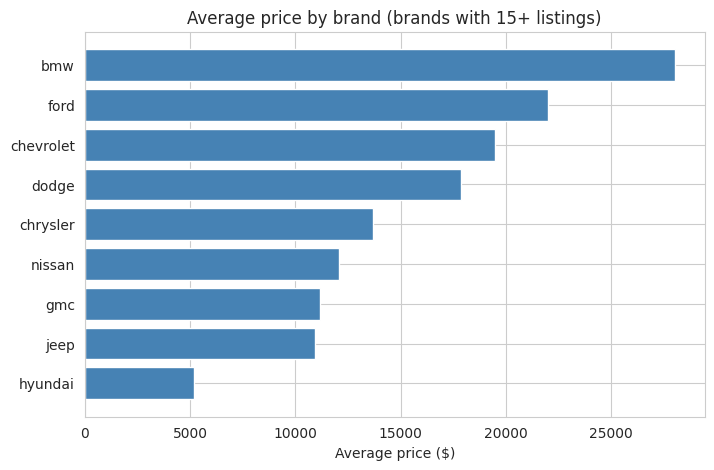

,brand,n,avg_price
0,bmw,16,28047.0
1,ford,1216,22003.0
2,chevrolet,283,19498.0
3,dodge,430,17865.0
4,chrysler,18,13686.0
5,nissan,312,12066.0
6,gmc,40,11190.0
7,jeep,30,10934.0
8,hyundai,15,5203.0


In [4]:
query = '''
SELECT brand, COUNT(*) AS n, ROUND(AVG(price), 0) AS avg_price
FROM listings
GROUP BY brand
HAVING n >= 15
ORDER BY avg_price DESC;
'''
brand_df = pd.read_sql_query(query, conn)

fig, ax = plt.subplots()
ax.barh(brand_df['brand'], brand_df['avg_price'], color='steelblue')
ax.set_xlabel('Average price ($)')
ax.set_title('Average price by brand (brands with 15+ listings)')
ax.invert_yaxis()
plt.show()

brand_df

Same ranking pandas found in phase 1 — BMW highest, Jeep and GMC lowest among brands with real sample sizes. Good sign: two different tools, same answer.

## 4. Clean title vs. salvage insurance, confirmed in SQL

In [5]:
query = '''
SELECT title_status, COUNT(*) AS n,
       ROUND(AVG(price), 0) AS avg_price,
       MIN(price) AS min_price, MAX(price) AS max_price
FROM listings
GROUP BY title_status;
'''
pd.read_sql_query(query, conn)

,title_status,n,avg_price,min_price,max_price
0,clean vehicle,2331,19921.0,720,84900
1,salvage insurance,117,3236.0,25,20000


Matches phase 1: salvage-insurance listings average roughly $3,200 against roughly $19,900 for clean titles — still the largest single price gap in the dataset.

## 5. Does region of the country matter?

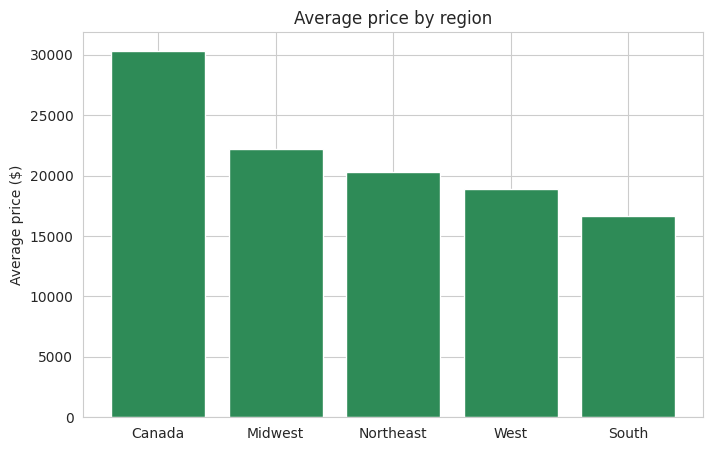

,region,n,avg_price
0,Canada,7,30357.0
1,Midwest,582,22190.0
2,Northeast,503,20334.0
3,West,374,18888.0
4,South,982,16696.0


In [6]:
query = '''
SELECT r.region, COUNT(*) AS n, ROUND(AVG(l.price), 0) AS avg_price
FROM listings l
JOIN regions r ON l.state = r.state
GROUP BY r.region
ORDER BY avg_price DESC;
'''
region_df = pd.read_sql_query(query, conn)

fig, ax = plt.subplots()
ax.bar(region_df['region'], region_df['avg_price'], color='seagreen')
ax.set_ylabel('Average price ($)')
ax.set_title('Average price by region')
plt.show()

region_df

This is new — phase 1 never looked at geography. The Midwest and Northeast run noticeably higher than the South; Canada's average looks highest of all, but that's only 7 listings, too few to trust. Worth a flag rather than a headline: real regional pattern in the US data, no real signal from the Canada row given the sample size.

## 6. Ranking brands within title status (window function)

A plain `GROUP BY` can aggregate, but it can't also rank rows within each group in the same query — that needs a window function, which computes something (here, a rank) *across* a partition of rows without collapsing them into one row per group the way `GROUP BY` does.

In [7]:
query = '''
SELECT brand, title_status, ROUND(AVG(price), 0) AS avg_price,
       RANK() OVER (PARTITION BY title_status ORDER BY AVG(price) DESC) AS price_rank
FROM listings
GROUP BY brand, title_status
HAVING COUNT(*) >= 10
ORDER BY title_status, price_rank;
'''
pd.read_sql_query(query, conn)

,brand,title_status,avg_price,price_rank
0,bmw,clean vehicle,31714.0,1
1,mercedes-benz,clean vehicle,28704.0,2
2,ford,clean vehicle,22846.0,3
3,buick,clean vehicle,21359.0,4
4,chevrolet,clean vehicle,20408.0,5
5,dodge,clean vehicle,18429.0,6
6,chrysler,clean vehicle,15384.0,7
7,infiniti,clean vehicle,13098.0,8
8,nissan,clean vehicle,12741.0,9
9,gmc,clean vehicle,12056.0,10


Chevrolet is the clearest mover: solidly mid-pack among clean titles but the cheapest of the four major brands once salvaged, while Ford holds its relative position in both groups. That's a brand-by-title_status interaction phase 1's brand-only chart couldn't show.

## 7. Which brands sell above the overall average?

In [8]:
query = '''
SELECT brand, ROUND(AVG(price), 0) AS avg_price
FROM listings
GROUP BY brand
HAVING avg_price > (SELECT AVG(price) FROM listings)
ORDER BY avg_price DESC;
'''
pd.read_sql_query(query, conn)

,brand,avg_price
0,lincoln,36300.0
1,lexus,33220.0
2,maserati,30300.0
3,land,28900.0
4,mercedes-benz,28704.0
5,bmw,28047.0
6,cadillac,27712.0
7,ford,22003.0
8,buick,21359.0
9,chevrolet,19498.0


The subquery in `HAVING` recomputes the overall average on the fly, so this stays correct even if the underlying data changes — no hardcoded number to go stale. Mostly luxury nameplates above the line, plus Ford, Buick, and Chevrolet as the non-luxury brands that still clear it.

## 8. From here to an actual dashboard

Everything above is a query I can run and a chart I can draw here — but a Power BI / Tableau dashboard needs its own desktop app, so that part happens on your end, not mine. Here's the concrete spec, straight from what these queries turned up:

**Connect the dashboard tool to `used_cars.db`** (or export `listings`/`regions` to CSV if the tool you're using can't read SQLite directly).

Build four visuals:
1. **KPI cards** — total listings, average price, median price (top of the dashboard)
2. **Bar chart** — average price by brand, filterable by title status
3. **Bar chart** — average price by region
4. **Scatter plot** — price vs. mileage, colored by title status (this is the one visual none of the SQL above produces, and it's the clearest single picture of what actually drives price)

Add one filter/slicer: **title status** (clean vehicle / salvage insurance), so the whole dashboard can toggle between "all listings" and "clean titles only" — the salvage group is skewing several of these averages down, and a real dashboard user would want to see both views.

## Key takeaways

- The two-table schema (`listings` + `regions`) isn't just structure for its own sake — it's what makes the region question answerable as a JOIN instead of a manual lookup.
- Every phase 1 finding held up in SQL: title status is still the biggest price driver, brand ranking is unchanged.
- Region is a genuinely new finding this phase surfaced — Midwest/Northeast price higher than the South, though the Canada figure isn't trustworthy at n=7.
- The window function surfaced something aggregation alone couldn't: brands don't hold their relative price rank the same way across title status — Chevrolet drops the furthest.
- Next: build the four-visual dashboard described above in Power BI or Tableau Public, then phase 3 — a price-prediction model combining mileage, year, title status, and brand.